# Демо по поиску аномалий

In [ ]:
# Импортируем необходимые библиотеки

import pandas as pd
import numpy as np

from sklearn.cluster import DBSCAN, AgglomerativeClustering, KMeans

%pylab inline

Populating the interactive namespace from numpy and matplotlib


In [ ]:
help(KMeans)

Help on class KMeans in module sklearn.cluster._kmeans:

class KMeans(_BaseKMeans)
 |  KMeans(n_clusters=8, *, init='k-means++', n_init='auto', max_iter=300, tol=0.0001, verbose=0, random_state=None, copy_x=True, algorithm='lloyd')
 |
 |  K-Means clustering.
 |
 |  Read more in the :ref:`User Guide <k_means>`.
 |
 |  Parameters
 |  ----------
 |
 |  n_clusters : int, default=8
 |      The number of clusters to form as well as the number of
 |      centroids to generate.
 |
 |      For an example of how to choose an optimal value for `n_clusters` refer to
 |      :ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.
 |
 |  init : {'k-means++', 'random'}, callable or array-like of shape             (n_clusters, n_features), default='k-means++'
 |      Method for initialization:
 |
 |      * 'k-means++' : selects initial cluster centroids using sampling             based on an empirical probability distribution of the points'             contribution to the overall ine

In [ ]:
# Загрузим данные

anomaly_df = pd.read_csv("anomaly_data.csv")
print(anomaly_df.shape)
anomaly_df.head()

(15830, 4)


,timestamp,value,is_anomaly,predicted
0,1425008573,42,False,44.072500
1,1425008873,41,False,50.709390
2,1425009173,41,False,81.405120
3,1425009473,61,False,39.950367
4,1425009773,44,False,35.350160


In [ ]:
# Посмотрим на данные
anomaly_df.describe()

,timestamp,value,predicted
count,1.583000e+04,15830.000000,15830.000000
mean,1.427383e+09,85.572205,71.870715
std,1.370962e+06,321.760918,92.450520
min,1.425009e+09,0.000000,-281.389070
25%,1.426196e+09,29.000000,32.919171
50%,1.427383e+09,47.000000,49.771124
75%,1.428570e+09,76.000000,75.948052
max,1.429757e+09,13479.000000,2716.127200


<Axes: >

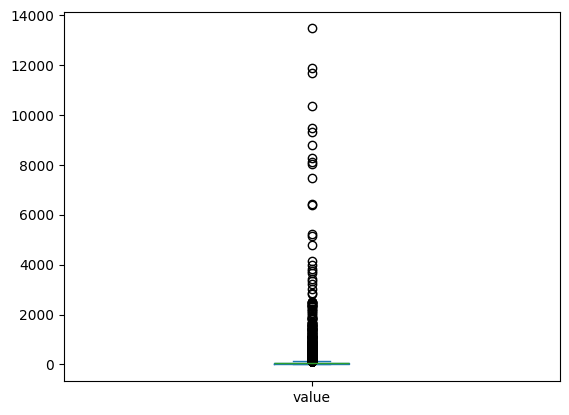

In [ ]:
anomaly_df['value'].plot(kind='box')

<Axes: ylabel='Frequency'>

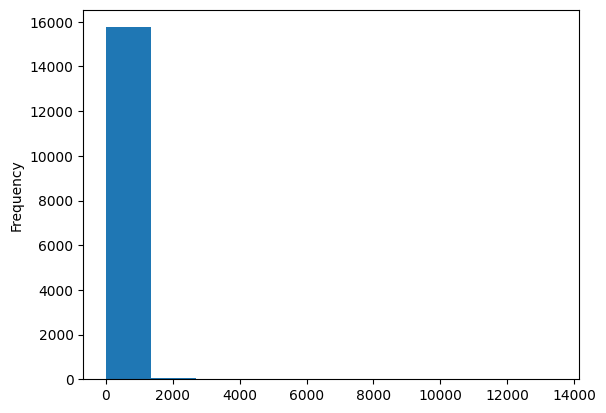

In [ ]:
anomaly_df['value'].plot(kind='hist')

## Поищем аномалии, с помощью DBSCAN

In [ ]:
dbscan = DBSCAN(eps=1)

In [ ]:
anomaly_df['prediction_dbscan_1'] = dbscan.fit_predict(anomaly_df['value'].values.reshape(-1, 1))
anomaly_df.head()

,timestamp,value,is_anomaly,predicted,prediction_dbscan_1
0,1425008573,42,False,44.072500,0
1,1425008873,41,False,50.709390,0
2,1425009173,41,False,81.405120,0
3,1425009473,61,False,39.950367,0
4,1425009773,44,False,35.350160,0


In [ ]:
# Обнаруженные аномалии
anomaly_df[anomaly_df.prediction_dbscan_1 < 0]

,timestamp,value,is_anomaly,predicted,prediction_dbscan_1
162,1425057173,456,True,89.710290,-1
163,1425057473,440,True,134.684600,-1
164,1425057773,477,True,126.210050,-1
1006,1425310373,346,True,68.731980,-1
1168,1425358973,446,True,71.947266,-1
...,...,...,...,...,...
15464,1429647773,2510,True,407.389860,-1
15465,1429648073,1299,True,388.840450,-1
15466,1429648373,714,False,456.416630,-1
15467,1429648673,576,False,323.319300,-1


## Поиск аномалий с помощью агломеративной кластеризации

In [ ]:
agglom = AgglomerativeClustering(n_clusters=None, distance_threshold=1)

In [ ]:
anomaly_df['prediction_agglom_1'] = agglom.fit_predict(anomaly_df['value'].values.reshape(-1, 1))
anomaly_df.head()

,timestamp,value,is_anomaly,predicted,prediction_dbscan_1,prediction_agglom_1
0,1425008573,42,False,44.072500,0,2
1,1425008873,41,False,50.709390,0,0
2,1425009173,41,False,81.405120,0,0
3,1425009473,61,False,39.950367,0,15
4,1425009773,44,False,35.350160,0,1


In [ ]:
valcount = anomaly_df['prediction_agglom_1'].value_counts()
valcount = set(valcount[valcount == 1].index)
anomaly_df[anomaly_df.prediction_agglom_1.isin(valcount)]

,timestamp,value,is_anomaly,predicted,prediction_dbscan_1,prediction_agglom_1
162,1425057173,456,True,89.710290,-1,630
164,1425057773,477,True,126.210050,-1,629
1168,1425358973,446,True,71.947266,-1,628
1360,1425416573,1698,True,101.339670,-1,607
1361,1425416873,3228,True,148.821490,-1,479
...,...,...,...,...,...,...
15465,1429648073,1299,True,388.840450,-1,462
15466,1429648373,714,False,456.416630,-1,390
15467,1429648673,576,False,323.319300,-1,396
15468,1429648973,490,False,348.968020,16,577


In [ ]:
# альтернативный подход -- считать аномалиями все точки из маленьких кластеров
labels = agglom.fit_predict(anomaly_df[['value']])
anomaly_df['cluster'] = labels
cluster_sizes = anomaly_df['cluster'].value_counts()

small_clusters = cluster_sizes[cluster_sizes <= 2].index
anomalies = anomaly_df[anomaly_df['cluster'].isin(small_clusters)]
anomalies

,timestamp,value,is_anomaly,predicted,prediction_dbscan_1,prediction_agglom_1,cluster
162,1425057173,456,True,89.71029,-1,630,630
163,1425057473,440,True,134.68460,-1,474,474
164,1425057773,477,True,126.21005,-1,629,629
165,1425058073,426,False,175.72702,2,539,539
1006,1425310373,346,True,68.73198,-1,494,494
...,...,...,...,...,...,...,...
15467,1429648673,576,False,323.31930,-1,396,396
15468,1429648973,490,False,348.96802,16,577,577
15470,1429649573,249,False,234.89127,0,131,131
15480,1429652573,297,False,191.65245,6,273,273
